# Hypothesis testing and statistical inference

This notebook uses the Adult Income dataset (`adult.data` and `adult.test`) and demonstrates various hypotheses testing.

The default significance level is **α = 0.05**.

## Getting ready

Import libraries.

In [1]:
# Import libraries

import numpy as np
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded.")


Libraries loaded.


## Load the data

The data was cleaned in the descriptive statistics notebook (missing values and duplicates deleted, income labels fixed). Run `Descriptive_statistics.ipynb` first to create the files in `cleaned_data`.

Hypothesis tests do not train a model, so there is nothing that could leak from the test data. We use all cleaned data (train and test together), because more data gives more reliable tests.

In [2]:
train = pd.read_csv("cleaned_data/train_clean.csv")
test = pd.read_csv("cleaned_data/test_clean.csv")

df = pd.concat([train, test], ignore_index=True)

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (45194, 22)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,...,hours-per-week,native-country,income,capital-gain-log,capital-loss-log,capital-net,has-capital,is-married,age-group,hours-category
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,...,40,United-States,<=50K,7.684784,0.0,2174,1,0,35-44,Full-time
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,...,13,United-States,<=50K,0.000000,0.0,0,0,1,45-54,Part-time
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,...,40,United-States,<=50K,0.000000,0.0,0,0,0,35-44,Full-time
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,...,40,United-States,<=50K,0.000000,0.0,0,0,1,45-54,Full-time
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,...,40,Cuba,<=50K,0.000000,0.0,0,0,1,25-34,Full-time


## Helper functions

The following functions make the output of the hypothesis tests easier to read.


In [3]:
ALPHA = 0.05

def decision(p_value, alpha=ALPHA):
    return "Reject H0" if p_value < alpha else "Do not reject H0"

def print_result(test_name, h0, h1, statistic_name, statistic, p_value, alpha=ALPHA):
    print("=" * 80)
    print(test_name)
    print("-" * 80)
    print("H0:", h0)
    print("H1:", h1)
    print(f"{statistic_name} = {statistic:.4f}")
    print(f"p-value = {p_value:.6f}")
    print(f"alpha = {alpha}")
    print("Decision:", decision(p_value, alpha))
    if p_value < alpha:
        print("Interpretation: There is statistically significant evidence against H0.")
    else:
        print("Interpretation: There is not sufficient statistical evidence against H0.")


# Test 1 — One sample *t*-test

### Example
Is the population average number of working hours per week equal to **40**?

$\begin{cases}
H_0: \mu = 40 \\
H_1: \mu \neq 40
\end{cases}$


Variable: `hours-per-week`

The Shapiro-Wilk test is performed because normality is an assumption of the one sample *t*-test.

# Shapiro-Wilk test for normality
Before performing One sample *t*-test, the Shapiro-Wilk normality test is performed to test wether population hours-per-week distribution is normal.

This tests the null hypothesis that the data was drawn from a normal distribution.

$\begin{cases}
H_0: \text{The population distribution is normal} \\
H_1: \text{The population distribution is not normal}
\end{cases}$

In [4]:
x = df["hours-per-week"].dropna()

stat, p_value = stats.shapiro(x)

print_result(
    test_name = "Shapiro-Wilk test for normality",
    h0 = "The population distribution is normal",
    h1 = "The population distribution is not normal",
    statistic_name = "w",
    statistic = stat,
    p_value = p_value
)

Shapiro-Wilk test for normality
--------------------------------------------------------------------------------
H0: The population distribution is normal
H1: The population distribution is not normal
w = 0.8792
p-value = 0.000000
alpha = 0.05
Decision: Reject H0
Interpretation: There is statistically significant evidence against H0.


C:\Users\mariz\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 45194.
  res = hypotest_fun_out(*samples, **kwds)


# One sample *t*-test

In [5]:
x = df["hours-per-week"].dropna()

mu0 = 40

# Two-sided alternative
t_stat, p_value = stats.ttest_1samp(x, popmean=mu0, alternative='two-sided')

# Right-sided alternative
#t_stat, p_value = stats.ttest_1samp(x, popmean=mu0, alternative='greater')

# Left-sided alternative
#t_stat, p_value = stats.ttest_1samp(x, popmean=mu0, alternative='less')

print_result(
    test_name = "One sample t-test",
    h0 = "μ = 40",
    h1 = "μ ≠ 40",
    statistic_name = "t",
    statistic = t_stat,
    p_value = p_value
)

print(f"Sample mean = {x.mean():.2f}")
print(f"Sample standard deviation = {x.std(ddof=1):.2f}")
print(f"Sample size = {len(x)}")


One sample t-test
--------------------------------------------------------------------------------
H0: μ = 40
H1: μ ≠ 40
t = 16.6653
p-value = 0.000000
alpha = 0.05
Decision: Reject H0
Interpretation: There is statistically significant evidence against H0.
Sample mean = 40.94
Sample standard deviation = 12.01
Sample size = 45194


### Conclusion

Shapiro-Wilk rejected normality of `hours-per-week` (p < 0.001), but with more than 45,000 rows the t-test can still be used (Central Limit Theorem).

p < 0.05, so we reject H0. The average working time is 40.94 hours per week, which is significantly different from 40 hours. The difference is small though, less than one hour.

# Test 2 — Hypothesis test for the population proportion

### Example
Is the population proportion of people earning more than 50K equal to **0.25** (or 25%)?

$\begin{cases}
H_0: p = 0.25 \\
H_1: p \neq 0.25
\end{cases}$


Variable: `income`

In [6]:
success = (df["income"] == ">50K").sum()
n = len(df)

p0 = 0.25

# Two-sided alternative
z_stat, p_value = proportions_ztest(count=success, nobs=n, value=p0, alternative="two-sided")

# Right-sided alternative
#z_stat, p_value = proportions_ztest(count=success, nobs=n, value=p0, alternative="larger")

# Left-sided alternative
#z_stat, p_value = proportions_ztest(count=success, nobs=n, value=p0, alternative="smaller")

print_result(
    test_name = "One sample population proportion test",
    h0 = "p = 0.25",
    h1 = "p ≠ 0.25",
    statistic_name = "z",
    statistic = z_stat,
    p_value = p_value
)

print(f"Observed proportion (income >50K) = {success/n:.2f}")
print(f"Successes (income >50K) = {success}")
print(f"n = {n}")


One sample population proportion test
--------------------------------------------------------------------------------
H0: p = 0.25
H1: p ≠ 0.25
z = -1.0076
p-value = 0.313640
alpha = 0.05
Decision: Do not reject H0
Interpretation: There is not sufficient statistical evidence against H0.
Observed proportion (income >50K) = 0.25
Successes (income >50K) = 11206
n = 45194


### Conclusion

p = 0.314 > 0.05, so we do not reject H0. The share of people earning more than 50K (24.80%) is not significantly different from 25%, so about one in four people earns more than 50K.

# Test 3 — Hypothesis testing for correlation

### Example
Is there a statistically significant linear correlation between the **age** of people and their **working hours per week**?

$\begin{cases}
H_0: \rho = 0 \\
H_1: \rho \neq 0
\end{cases}$

Variables:
- `age`
- `hours-per-week`

The Shapiro-Wilk test is performed for both variables before testing for correlation.

In [7]:

x = df["age"].dropna()

stat, p_value = stats.shapiro(x)

print_result(
    test_name = "Shapiro-Wilk test for normality: Age",
    h0 = "The population distribution is normal",
    h1 = "The population distribution is not normal",
    statistic_name = "w",
    statistic = stat,
    p_value = p_value
)

x = df["hours-per-week"].dropna()

stat, p_value = stats.shapiro(x)

print_result(
    test_name = "Shapiro-Wilk test for normality: Hours per week",
    h0 = "The population distribution is normal",
    h1 = "The population distribution is not normal",
    statistic_name = "w",
    statistic = stat,
    p_value = p_value
)

corr_data = df[["age", "hours-per-week"]].dropna()

r, p_value = stats.pearsonr(corr_data["age"], corr_data["hours-per-week"], alternative='two-sided')

print_result(
    test_name = "Hypothesis test for correlation",
    h0 = "ρ = 0",
    h1 = "ρ ≠ 0",
    statistic_name = "r",
    statistic = r,
    p_value = p_value
)

print(f"n = {len(corr_data)}")


Shapiro-Wilk test for normality: Age
--------------------------------------------------------------------------------
H0: The population distribution is normal
H1: The population distribution is not normal
w = 0.9703
p-value = 0.000000
alpha = 0.05
Decision: Reject H0
Interpretation: There is statistically significant evidence against H0.
Shapiro-Wilk test for normality: Hours per week
--------------------------------------------------------------------------------
H0: The population distribution is normal
H1: The population distribution is not normal
w = 0.8792
p-value = 0.000000
alpha = 0.05
Decision: Reject H0
Interpretation: There is statistically significant evidence against H0.
Hypothesis test for correlation
--------------------------------------------------------------------------------
H0: ρ = 0
H1: ρ ≠ 0
r = 0.1017
p-value = 0.000000
alpha = 0.05
Decision: Reject H0
Interpretation: There is statistically significant evidence against H0.
n = 45194


C:\Users\mariz\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 45194.
  res = hypotest_fun_out(*samples, **kwds)


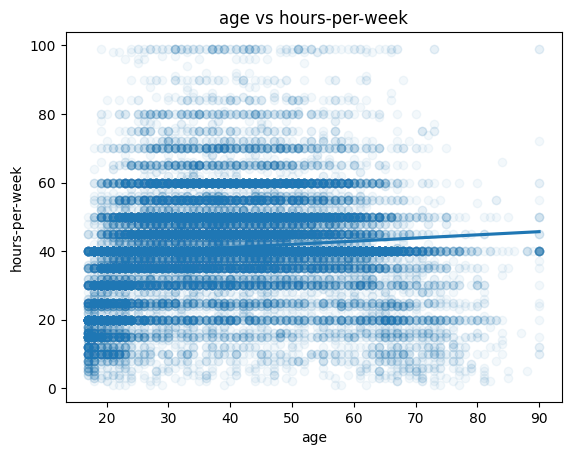

In [8]:
sns.regplot(
    data=corr_data,
    x="age",
    y="hours-per-week",
    ci=None,
    scatter_kws={"alpha": 0.05}
)
plt.title("age vs hours-per-week")
plt.show()

### Conclusion

Neither variable is normally distributed (Shapiro-Wilk p < 0.001), but because the sample is large we can still use the Pearson test.

p < 0.05, so we reject H0. Age and working hours are significantly correlated, but the correlation is very weak (r = 0.10). The scatter plot shows the same, age says very little about how many hours someone works.

# Test 4 — Two independent samples *t*-test

### Example

Do women and men work a different average number of **hours per week**?

The hypotheses are:

$\begin{cases}
H_0: \mu_x = \mu_y \\
H_1: \mu_x \neq \mu_y
\end{cases}$

Before performing the independent-samples *t*-test, the **equality** of the two **population variances** is checked using **Levene's test**.

The hypotheses of Levene's test are:

$\begin{cases}
H_0: \sigma^2_x = \sigma^2_y \\
H_1: \sigma^2_x \neq \sigma^2_y
\end{cases}$

- If the Levene's test *p*-value $p \geq 0.05$, there is insufficient evidence to conclude that the variances are different. The independent samples *t*-test with the **equal variances** assumption is then used.
- If the Levene's test *p*-value $p \lt 0.05$, the null hypothesis of equal variances is rejected. The independent samples *t*-test with the **unequal variances** assumption is then used. In this case, **Welch's independent samples *t*-test**, which does not assume equal population variances, is used.

Therefore, the procedure is:

1. Test the equality of variances using Levene's test.
2. If the variances can be treated as equal, use the standard independent samples *t*-test.
3. If the variances are significantly different, use Welch's *t*-test.

The Shapiro-Wilk test is also performed separately for female and male working hours to assess the normality assumption.

Variables:
- Grouping variable: `sex`
- Measurement variable: `hours-per-week`



In [9]:
# Prepare data

ind_data = df[["sex", "hours-per-week"]].copy()

ind_data["hours-per-week"] = pd.to_numeric(
    ind_data["hours-per-week"],
    errors="coerce"
)

ind_data["Gender_clean"] = (
    ind_data["sex"]
    .astype(str)
    .str.strip()
    .str.lower()
)

ind_data = ind_data.dropna(
    subset=["hours-per-week", "Gender_clean"]
)

female = ind_data.loc[
    ind_data["Gender_clean"] == "female",
    "hours-per-week"
]

male = ind_data.loc[
    ind_data["Gender_clean"] == "male",
    "hours-per-week"
]

print(f"Female: n = {len(female)}, mean = {female.mean():.4f}, "
      f"variance = {female.var(ddof=1):.4f}")

print(f"Male: n = {len(male)}, mean = {male.mean():.4f}, "
      f"variance = {male.var(ddof=1):.4f}")


# Test normality using Shapiro-Wilk test

stat, p_value = stats.shapiro(female)

print_result(
    test_name = "Shapiro-Wilk test for normality: Hours per week for Female",
    h0 = "The population distribution is normal",
    h1 = "The population distribution is not normal",
    statistic_name = "w",
    statistic = stat,
    p_value = p_value
)

stat, p_value = stats.shapiro(male)

print_result(
    test_name = "Shapiro-Wilk test for normality: Hours per week for Male",
    h0 = "The population distribution is normal",
    h1 = "The population distribution is not normal",
    statistic_name = "w",
    statistic = stat,
    p_value = p_value
)

# Test equality of variances using Levene's test

print("\n--- Levene's test for equality of variances ---")

levene_stat, levene_p = stats.levene(female, male, center="median")

print(f"Levene statistic = {levene_stat:.4f}")
print(f"Levene p-value = {levene_p:.4f}")

if levene_p < ALPHA:
    print(
        f"p-value < {ALPHA}: Reject H0."
    )
    print(
        "There is evidence that the population variances are different."
    )
    equal_variances = False
else:
    print(
        f"p-value >= {ALPHA}: Do not reject H0."
    )
    print(
        "There is insufficient evidence that the population variances are different."
    )
    equal_variances = True


# Select and perform the appropriate t-test

print("\n--- Independent samples t-test ---")

if equal_variances:
    # Equal variances assumed
    t_stat, p_value = stats.ttest_ind(female, male, equal_var=True)
    selected_test = "Independent samples t-test (equal variances assumed)"
else:
    # Equal variances not assumed
    t_stat, p_value = stats.ttest_ind(female, male, equal_var=False)
    selected_test = "Welch's independent samples t-test"

print(f"Selected test: {selected_test}")

print_result(
    test_name = "Two independent-samples t-test",
    h0 = "μ_x = μ_y",
    h1 = "μ_x ≠ μ_y",
    statistic_name = "t",
    statistic = t_stat,
    p_value = p_value
)

print(f"Female sample mean = {female.mean():.4f}, n = {len(female)}")
print(f"Male sample mean = {male.mean():.4f}, n = {len(male)}")

Female: n = 14685, mean = 36.9366, variance = 133.4515
Male: n = 30509, mean = 42.8688, variance = 137.8763
Shapiro-Wilk test for normality: Hours per week for Female
--------------------------------------------------------------------------------
H0: The population distribution is normal
H1: The population distribution is not normal
w = 0.8775
p-value = 0.000000
alpha = 0.05
Decision: Reject H0
Interpretation: There is statistically significant evidence against H0.
Shapiro-Wilk test for normality: Hours per week for Male
--------------------------------------------------------------------------------
H0: The population distribution is normal
H1: The population distribution is not normal
w = 0.8672
p-value = 0.000000
alpha = 0.05
Decision: Reject H0
Interpretation: There is statistically significant evidence against H0.

--- Levene's test for equality of variances ---
Levene statistic = 0.1482
Levene p-value = 0.7003
p-value >= 0.05: Do not reject H0.
There is insufficient evidence tha

C:\Users\mariz\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 14685.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\mariz\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 30509.
  res = hypotest_fun_out(*samples, **kwds)


### Conclusion

Levene's test did not reject equal variances (p = 0.700), so we used the standard t-test.

p < 0.05, so we reject H0. Women work on average 36.94 hours per week and men 42.87 hours, so men work about 6 hours more.

# Test 6 — Equality of two population proportions

### Example
Are the population proportions of people earning more than 50K equal for **women** and **men**?

$\begin{cases}
H_0: p_F = p_M \\
H_1: p_F \neq p_M
\end{cases}$


Variables:
- `sex`
- `income`

In [10]:
female = df[df["sex"] == "Female"]
male = df[df["sex"] == "Male"]

success_F = (female["income"] == ">50K").sum()
success_M = (male["income"] == ">50K").sum()

n_F = len(female)
n_M = len(male)

z_stat, p_value = proportions_ztest(
    count=[success_F, success_M],
    nobs=[n_F, n_M],
    alternative="two-sided"
)

print_result(
    test_name = "Equality of two population proportions",
    h0 = "p_F = p_M",
    h1 = "p_F ≠ p_M",
    statistic_name = "z",
    statistic = z_stat,
    p_value = p_value
)

print(f"Female sample proportion (>50K) = {success_F/n_F:.4f}")
print(f"Male sample proportion (>50K) = {success_M/n_M:.4f}")

Equality of two population proportions
--------------------------------------------------------------------------------
H0: p_F = p_M
H1: p_F ≠ p_M
z = -45.8703
p-value = 0.000000
alpha = 0.05
Decision: Reject H0
Interpretation: There is statistically significant evidence against H0.
Female sample proportion (>50K) = 0.1137
Male sample proportion (>50K) = 0.3126


### Conclusion

p < 0.05, so we reject H0. 11.4% of women earn more than 50K and 31.3% of men, so for men it is almost three times as common.

# Test 8 — Chi-square (χ²) goodness-of-fit test

### Example
Does the population distribution of **sex** follow the expected distribution:

- Female = 0.50 (50%)
- Male = 0.50 (50%)

$\begin{cases}
H_0: p_1 = 0.50, p_2 = 0.50 \\
H_1: \text{At least one } p_i \neq p_{i}^{0} (i=1, 2)
\end{cases}$


Variable: `sex`

In [11]:
sex_values = df["sex"].dropna().astype(str).str.strip()

categories = ["Female", "Male"]
observed = sex_values.value_counts().reindex(categories, fill_value=0).values
hypothesized_proportions = np.array([0.50, 0.50])
expected = sex_values.size * hypothesized_proportions

chi2_stat, p_value = stats.chisquare(observed, expected)

print_result(
    test_name = "Chi-square goodness-of-fit test",
    h0 = "p_1 = 0.50, p_2 = 0.50",
    h1 = "At least one population proportion differs",
    statistic_name = "χ²",
    statistic = chi2_stat,
    p_value = p_value
)

display(pd.DataFrame({
    "Category": categories,
    "Observed": observed,
    "Expected": expected,
    "Observed proportion": observed / observed.sum(),
    "Expected proportion": hypothesized_proportions
}))


Chi-square goodness-of-fit test
--------------------------------------------------------------------------------
H0: p_1 = 0.50, p_2 = 0.50
H1: At least one population proportion differs
χ² = 5540.5358
p-value = 0.000000
alpha = 0.05
Decision: Reject H0
Interpretation: There is statistically significant evidence against H0.


,Category,Observed,Expected,Observed proportion,Expected proportion
0,Female,14685,22597.0,0.324933,0.5
1,Male,30509,22597.0,0.675067,0.5


### Conclusion

p < 0.05, so we reject H0. The data is not 50/50: 32.5% women and 67.5% men. Men are overrepresented, which is important for the other results too.

# Test 9 — Chi-square (χ²) test of independence

### Example
Is **education** level independent of **income**?

$\begin{cases}
H_0: \text{Education and Income are independent} \\
H_1: \text{Education and Income are dependent}
\end{cases}$

Variables:
- `education`
- `income`

In [12]:
ind_table = pd.crosstab(df["education"], df["income"])

chi2_stat, p_value, dof, expected = stats.chi2_contingency(ind_table)

print_result(
    test_name = "Chi-square test of independence",
    h0 = "Education and Income are independent",
    h1 = "Education and Income are dependent",
    statistic_name = "χ²",
    statistic = chi2_stat,
    p_value = p_value
)

print("\nObserved frequencies:")
display(ind_table)
print("Expected frequencies:")
display(pd.DataFrame(expected, index=ind_table.index, columns=ind_table.columns))

Chi-square test of independence
--------------------------------------------------------------------------------
H0: Education and Income are independent
H1: Education and Income are dependent
χ² = 5996.0353
p-value = 0.000000
alpha = 0.05
Decision: Reject H0
Interpretation: There is statistically significant evidence against H0.

Observed frequencies:


income,<=50K,>50K
education,,
10th,1141,82
11th,1530,89
12th,533,43
1st-4th,212,8
5th-6th,426,22
7th-8th,767,55
9th,638,38
Assoc-acdm,1109,398
Assoc-voc,1454,504


Expected frequencies:


income,<=50K,>50K
education,,
10th,919.753153,303.246847
11th,1217.563659,401.436341
12th,433.178918,142.821082
1st-4th,165.450281,54.549719
5th-6th,336.916936,111.083064
7th-8th,618.182414,203.817586
9th,508.383591,167.616409
Assoc-acdm,1133.334425,373.665575
Assoc-voc,1472.507501,485.492499


### Conclusion

p < 0.05, so we reject H0. Education and income are dependent. The share earning more than 50K goes up with education: 1.4% for Preschool, 16.3% for HS-grad, 42.0% for Bachelors and over 73% for Doctorate and Prof-school.

# Test 10 — Chi-square (χ²) test of homogeneity

### Example
Is the distribution of **income** the same across the five **race** groups?

$\begin{cases}
H_0: \text{The distribution of income is the same across the five race groups} \\
H_1: \text{At least one race group has a different distribution}
\end{cases}$


Variables:
- `race`
- `income`

In [13]:
hom_table = pd.crosstab(df["race"], df["income"])

chi2_stat, p_value, dof, expected = stats.chi2_contingency(hom_table)

print_result(
    test_name = "Chi-square test of homogeneity",
    h0 = "Income has the same distribution across race groups",
    h1 = "At least one race group has a different distribution",
    statistic_name = "χ²",
    statistic = chi2_stat,
    p_value = p_value
)

print("\nObserved frequencies:")
display(hom_table)
print("Expected frequencies:")
display(pd.DataFrame(expected, index=hom_table.index, columns=hom_table.columns))


Chi-square test of homogeneity
--------------------------------------------------------------------------------
H0: Income has the same distribution across race groups
H1: At least one race group has a different distribution
χ² = 452.7498
p-value = 0.000000
alpha = 0.05
Decision: Reject H0
Interpretation: There is statistically significant evidence against H0.

Observed frequencies:


income,<=50K,>50K
race,,
Amer-Indian-Eskimo,382,53
Asian-Pac-Islander,933,369
Black,3693,534
Other,308,45
White,28672,10205


Expected frequencies:


income,<=50K,>50K
race,,
Amer-Indian-Eskimo,327.140328,107.859672
Asian-Pac-Islander,979.164845,322.835155
Black,3178.901536,1048.098464
Other,265.472496,87.527504
White,29237.320795,9639.679205


### Conclusion

p < 0.05, so we reject H0. Income is not distributed the same way in all race groups. The share earning more than 50K is highest for Asian-Pac-Islander (28.3%) and White (26.2%), and around 12-13% for Black, Other and Amer-Indian-Eskimo. Some groups are small (only 353 people in Other), so their results are less reliable.